Dimensões do dataset: (856, 5)

---Linhas com valores ausentes---
Linha 3:
Mês/Ano                             08/2023
Região                             NORDESTE
Estado                              Alagoas
Produção Etanol Hidratado(m³/d)       855.0
Produção Etanol Anidro (m³/d)           NaN
Name: 3, dtype: object
Linha 10:
Mês/Ano                            08/2023
Região                               NORTE
Estado                                  GO
Produção Etanol Hidratado(m³/d)     1004.0
Produção Etanol Anidro (m³/d)          NaN
Name: 10, dtype: object
Linha 15:
Mês/Ano                                   08/2023
Região                                        NaN
Estado                             Rio de Janeiro
Produção Etanol Hidratado(m³/d)               NaN
Produção Etanol Anidro (m³/d)                 NaN
Name: 15, dtype: object
Linha 18:
Mês/Ano                                      08/2023
Região                                           SUL
Estado                           

/tmp/ipython-input-3107778223.py:235: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_tratado[coluna].fillna(df_tratado[coluna].median(), inplace=True)
/tmp/ipython-input-3107778223.py:265: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

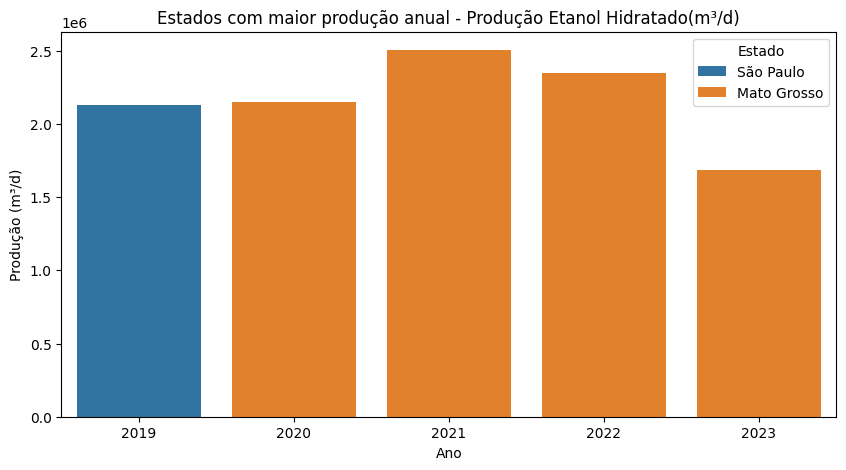

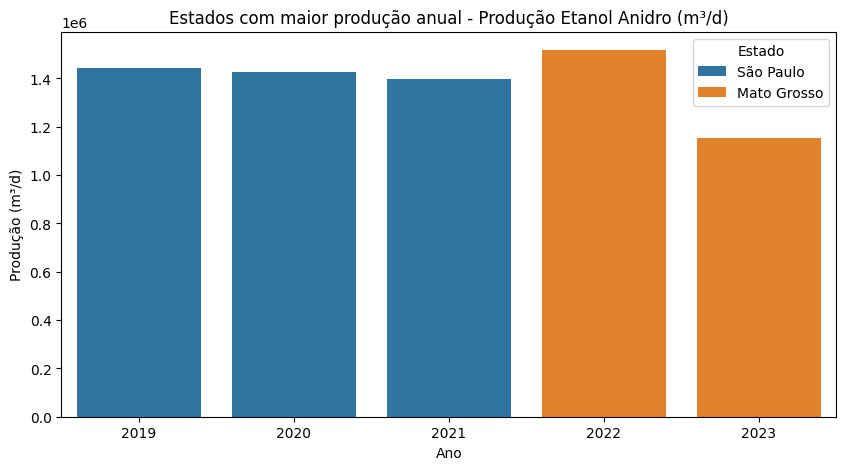

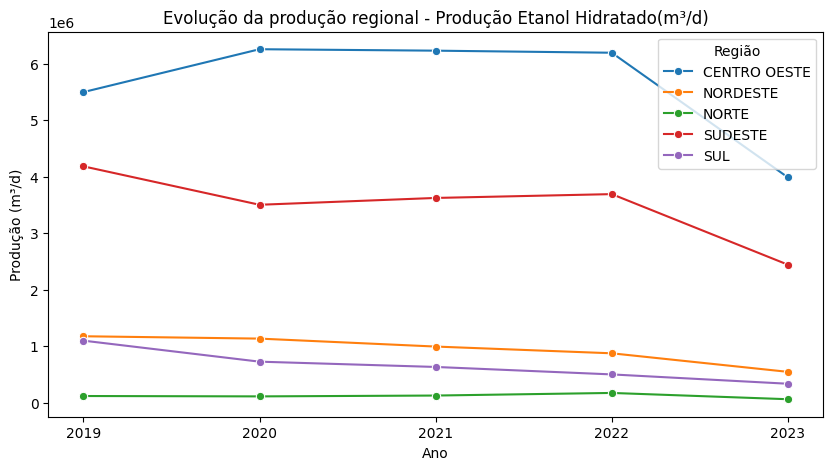

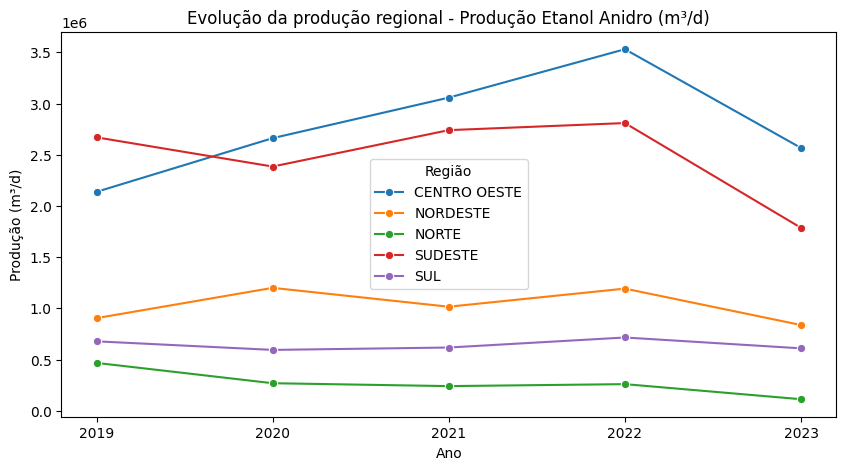

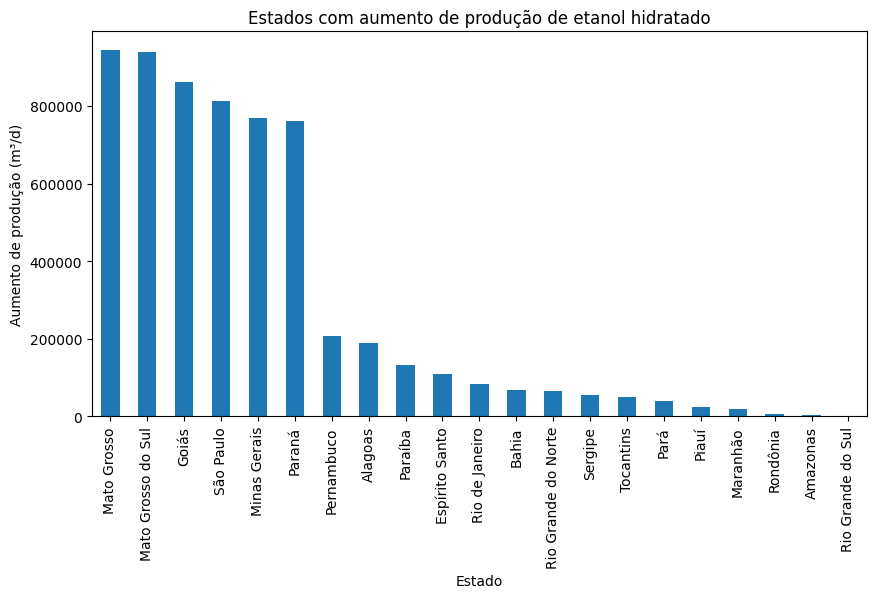

Nenhum estado ficou abaixo do desvio padrão do etanol anidro em nenhum ano


In [ ]:
import pandas as pd
import numpy as np
import unicodedata
import re
import seaborn as sns
import matplotlib.pyplot as plt

# Carregamento do dataset
url = "https://raw.githubusercontent.com/ccalmendra/ciencia-dados/refs/heads/main/dados/ap2-combustivel-producao.csv"
df = pd.read_csv(url)

print("Dimensões do dataset:", df.shape)


# Função para normalizar textos, removendo acentos e caracteres especiais
def normalizar_texto(txt):
    # Verifica se o input é vazio ou None, retorna string vazia se for o caso
    if not txt:
        return ""

    # Normaliza o texto removendo acentos
    # NFKD = Normalization Form Compatibility Decomposition
    #unicodedata.combining(c) = remove os caracteres de acento, que foram separados pela normalização.
    txt_normalizado = ''.join(
        c for c in unicodedata.normalize('NFKD', txt)
        if not unicodedata.combining(c)
    )

    # Converte o texto normalizado para letras minúsculas
    txt_normalizado_lower = txt_normalizado.lower()

    # Remove caracteres que não sejam letras, números ou espaços
    # [^a-z0-9 ] = remove qualquer caractere que não seja letra minúscula, número ou espaço
    txt_sem_pontuacao = re.sub(r"[^a-z0-9 ]", " ", txt_normalizado_lower)

    # Remove múltiplos espaços extras
    txt_limpo = " ".join(txt_sem_pontuacao.split())

    return txt_limpo

#---------Parte 1 - Identificação--------------

# 1.1 - Detectar e exibir linhas com valores ausentes
print("\n---Linhas com valores ausentes---")
for idx, row in df.iterrows():
    if row.isna().any():
        print(f"Linha {idx}:")
        print(row)

# 1.2 - Contagem de valores ausentes por coluna
print("\nContagem de valores ausentes por coluna:")
print(df.isna().sum())

# 1.3 - Extrair Ano e Mês da coluna 'Mês/Ano' para uso posterior
df['Ano'] = df['Mês/Ano'].astype(str).str.extract(r'(\d{4})')
df['Mês'] = df['Mês/Ano'].astype(str).str.extract(r'(\d{1,2})')
#.str.extract(r'(\d{4})') e str.extract(r'(\d{1,2})'): Usa uma expressão regular para buscar exatamente quatro e dois digitos consecutivos dentro da string respectivamente. se nao encontrar retorna nan

# 1.4 - Detectar linhas duplicadas com base nas chaves (Estado, Ano, Mês)
print("\n---Linhas duplicadas (Estado, Ano, Mês)---")

colunas_chave = ["Estado", "Ano", "Mês"]

colunas_duplicatas = df.duplicated(subset=colunas_chave, keep=False)
linhas_duplicadas = df[colunas_duplicatas].sort_values(colunas_chave)

print(linhas_duplicadas)

print(f"Total de duplicadas = {len(linhas_duplicadas)}")

# 1.5 - Detectar outliers nas colunas de volume usando método IQR
colunas_volume = ['Produção Etanol Hidratado(m³/d)', 'Produção Etanol Anidro (m³/d)']

limites_outliers = {}

for col in colunas_volume:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limites_outliers[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    #Limite inferior: Q1 - 1.5 * IQR, Limite superior: Q3 + 1.5 * IQR

print("\n--- Linhas com outliers ---")

total_outliers = 0

for idx, row in df.iterrows():
    for col in colunas_volume:
        valor = row[col]
        limite_inf, limite_sup = limites_outliers[col]

        if pd.notna(valor) and (valor < limite_inf or valor > limite_sup):
            print(f"Linha {idx} / Coluna {col} / Valor {valor}")
            print(row)
            total_outliers += 1

#pd.notna(valor) garante que o valor não seja NaN (ausente).O valor é comparado com os limites inferior e superior. Se estiver fora do intervalo, a linha, coluna e valor do outlier são impressos

print(f"Total de outliers = {total_outliers}")


# 1.6 - Detectar valores negativos em colunas de volume

print("\n--- Valores negativos em colunas de volume ---")

total_negativos = 0

for idx, row in df.iterrows():
    for col in colunas_volume:
        if pd.notna(row[col]) and row[col] < 0:
            print(f"Linha {idx} possui valor negativo em {col}")
            print(row)
            total_negativos += 1

#Detecta valores: não nulos e negativos

print(f"Total de valores negativos = {total_negativos}")


# 1.7 - Validar meses (deve estar entre 01 e 12)

meses_validos = {
    "01","02","03","04","05","06",
    "07","08","09","10","11","12"
}
#Padrao do dataset

print("\n---Meses inválidos---")

total_meses_invalidos = 0

for idx, row in df.iterrows():
    if row["Mês"] not in meses_validos:
        print(f"Linha {idx} com mês inválido: {row['Mês']}")
        print(row)
        total_meses_invalidos += 1

print(f"Total de meses inválidos = {total_meses_invalidos}")

# 1.8 - Validar anos (esperado entre 2019 e 2023)
anos_validos = {
    "2019", "2020","2021","2022", "2023"
}
#Padrao do dataset

print("\nAnos inválidos: ")

total_ano_invalidos = 0

for idx, row in df.iterrows():
    if row["Ano"] not in anos_validos:
        print(f"Linha {idx} com ano inválido: {row['Ano']}")
        print(row)
        total_ano_invalidos += 1

print(f"Total de anos inválidos = {total_ano_invalidos}")

# 1.9 - Validar regiões
regioes_validas = {"NORTE", "NORDESTE", "CENTRO OESTE", "SUDESTE", "SUL"}
#Padrao do dataset
print("\nRegiões inválidas: ")

total_regioes_invalidos = 0

for idx, row in df.iterrows():
    if row["Região"] not in regioes_validas:
        print(f"Linha {idx} com região inválido: {row['Região']}")
        print(row)
        total_regioes_invalidos += 1

print(f"Total de regioes inválidos = {total_regioes_invalidos}")

# 1.10 - Normalizar e validar nomes de estados

UF_estado = {

    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas", "BA": "Bahia", "CE": "Ceará",
    "DF": "Distrito Federal", "ES": "Espírito Santo", "GO": "Goiás", "MA": "Maranhão", "MT": "Mato Grosso",
    "MS": "Mato Grosso do Sul", "MG": "Minas Gerais", "PA": "Pará", "PB": "Paraíba", "PR": "Paraná",
    "PE": "Pernambuco", "PI": "Piauí", "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte", "RS": "Rio Grande do Sul",
    "RO": "Rondônia", "RR": "Roraima", "SC": "Santa Catarina", "SP": "São Paulo", "SE": "Sergipe", "TO": "Tocantins"

}

nomes_estados = set(UF_estado.values())

# Função para padronizar nomes de estados (sigla)
def padronizar_estado(valor):
    if pd.isna(valor) or str(valor).strip() == "":
        return np.nan
    s = str(valor).strip() #Garante que valor seja uma string limpa, sem espaços no começo ou fim.

    # Se a string tem exatamente 2 letras e todas são caracteres alfabéticos, assume que é uma sigla de estado.Usa  dicionário UF_estado  para tentar obter o nome do estado. Se a sigla não estiver no dicionário, retorna np.nan.
    if len(s) == 2 and s.isalpha():
        return UF_estado.get(s.upper(), np.nan)

    # Se for nome, tenta normalizar e reconhecer
    s_norm = normalizar_texto(s)
    for nome in nomes_estados:
        if normalizar_texto(nome) == s_norm:
            return nome

    return np.nan

# Verifica estados inválidos
print("\n--- Estados inválidos ---")

contador_estados_invalidos = 0

for idx, row in df.iterrows():
    estado_padronizado = padronizar_estado(row["Estado"])
    if pd.isna(estado_padronizado):
        print(f"Linha {idx} com estado inválido: {row['Estado']}")
        print(row)
        contador_estados_invalidos += 1

print(f"Total de estados inválidos = {contador_estados_invalidos}")

#-----------------Parte 2 - Tratamento-----------------

# Cria uma cópia do DataFrame original antes do tratamento
df_tratado = df.copy()

# 2.1 - Remoção de duplicatas com base nas chaves (Estado, Ano, Mês)
df_tratado = df_tratado.drop_duplicates(subset=colunas_chave, keep="first").copy()
print("Após remover duplicatas:", df_tratado.shape)

# 2.2 - Tratamento de valores ausentes em colunas de volume

#Sugestão: preencher valores ausentes com a mediana

#Justificativa: preencher com a mediana mantém a quantidade de dados, ideal quando a quantidade de valores ausentes é pequena e os dados são relativamente homogêneos, e nao é influenciada por outliers

for coluna in colunas_volume:
    df_tratado[coluna].fillna(df_tratado[coluna].median(), inplace=True)

# 2.3 - Tratamento de outliers nas colunas de volume usando limites do IQR

#Sugestão: preencher valores outliers com o limite inferior ou superior

#Justificativa: Essa técnica evita que valores extremos influenciem análises futuras e mantém a consistência dos dados. Substituir os outliers pelos limites ajuda a suavizar valores extremos sem perder informações importantes. Como alternativa, também poderia substituir por média ou mediana, mas neste caso optei por limitar os valores aos limites calculados pelo método do IQR, que é robusto.

for coluna in colunas_volume:
    limite_inf, limite_sup = limites_outliers[coluna]
    df_tratado.loc[df_tratado[coluna] < limite_inf, coluna] = limite_inf
    df_tratado.loc[df_tratado[coluna] > limite_sup, coluna] = limite_sup



# 2.4 - Normalizar nomes de estados

#Sugestão: Normalizar as letras de estado
#Justificativa: normalizar as letras acaba com a aparição de estados inválidos. Todos os estados inválidos apareceram pois nao tinham acentos e a lista de estados válidos anteriormente tinha acentos

df_tratado["Estado"] = df_tratado["Estado"].apply(padronizar_estado)

# 2.5 - Tratamento de anos inválidos

#Sugestao: Remover caracteres extras, espaços ou textos anexados ao valor original do ano. A expressão regular irá extrair apenas os quatro dígitos que representam o ano. Caso o valor não siga o padrão esperado, a extração retornará NaN que em seguida sera preenchida com a moda dos anos

#Justificativa: Substituir anos inválidos ou não padronizados pela moda da coluna não altera significativamente o dataset original e evita impactos negativos nas análises

df_tratado["Ano"] = df_tratado["Ano"].astype(str).str.extract(r'(\d{4})')
#.str.extract(r'(\d{4})'): Usa uma expressão regular para buscar exatamente quatro dígitos consecutivos dentro da string
df_tratado["Ano"].fillna(df_tratado["Ano"].mode()[0], inplace=True)

# 2.6 - Tratamento de meses inválidos

#Sugestão: Tratar a unica linha com o mes inválido individualmente

#Justificativa: Como so existe uma linha com mês inválido sendo ela: Linha 6 com mês inválido: 2023-08 fiz essa função para tratar ela especificamente (nao fiz fill nan pois nao  existe nenhum mes nan)

for idx, row in df_tratado.iterrows():
    mes_ano = row["Mês/Ano"]
    if isinstance(mes_ano, str) and "-" in mes_ano:
        partes = mes_ano.split("-")
        if len(partes) == 2:
            df_tratado.at[idx, "Ano"] = partes[0]
            df_tratado.at[idx, "Mês"] = partes[1]

# 2.7 - Tratamento de regiões inválidas ou ausentes

# Sugestão: Padronizar os valores da coluna "Região" (remoção de espaços extras e conversão para letras maiúsculas) e substituir valores ausentes (NaN) pela moda da coluna.

# Justificativa: A padronização evita a criação de categorias inconsistentes causadas por variações de escrita(ex.: diferenças de caixa ou espaços em branco). A substituicao pela moda é adequada para variáveis categóricas, pois preserva o tamanho do conjunto de dados e mantém a categoria mais frequente,minimizando distorções na análise sem a necessidade de remover observações (dropna).

df_tratado["Região"] = (df_tratado["Região"].where(df_tratado["Região"].notna()).str.strip().str.upper()) # notna: filtra os nan para que nao sejam tratados como string
df_tratado["Região"].fillna(df_tratado["Região"].mode()[0], inplace=True)



#---------------Parte 3 - Análise de gráfico-----------------

# 3.1 - Identificação dos estados com maior produção de cada combustível por ano
top_estados = (df_tratado.groupby(["Ano", "Estado"])[colunas_volume].sum().reset_index())

for col in colunas_volume:
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=top_estados.loc[top_estados.groupby("Ano")[col].idxmax()],x="Ano",y=col,hue="Estado")
    #idxmax() = Seleciona o estado com maior produção por ano.
    plt.title(f"Estados com maior produção anual - {col}")
    plt.ylabel("Produção (m³/d)")
    plt.xlabel("Ano")
    plt.show()

#Análise: Observa-se que Mato grosso e sao paulo dominam a produção anual tanto de etanol hidratado quanto de etanol anidro em todos os anos.Isso evidencia a forte concentração da indústria nos estados.

# 3.2 - Evolução da produção por região ao longo dos anos
producao_regiao = (df_tratado.groupby(["Ano", "Região"])[colunas_volume].sum().reset_index())

for col in colunas_volume:
    plt.figure(figsize=(10,5))
    sns.lineplot(
        data=producao_regiao,x="Ano",y=col,hue="Região",marker="o")
    plt.title(f"Evolução da produção regional - {col}")
    plt.ylabel("Produção (m³/d)")
    plt.xlabel("Ano")
    plt.show()

#Análise: A região Centro-Oeste e Sudeste apresentam os maiores volumes de produção ao longo de todo o período, mantendo crescimento relativamente estável. O resto das regiões possuem valores de volumes muito menores. No ano de 2022 a 2023 nota-se que todas as regiões nos dois tipos de Etanol apresentaram um decréscimo significativo possivelmente por alguma alteração no preço da gasolina.


# 3.3 - Estados com aumento de produção de etanol hidratado ao longo do período (Considerando que o dataset não possui gasolina, usei o etanol hidratado para análise)

producao_estado_ano = (df_tratado.groupby(["Estado", "Ano"])["Produção Etanol Hidratado(m³/d)"].sum().reset_index())

crescimento = (producao_estado_ano.pivot(index="Estado", columns="Ano", values="Produção Etanol Hidratado(m³/d)"))

#Pivot: Transforma o DataFrame para que cada estado seja uma linha e cada ano uma coluna. Valores: Os valores nas células representam a produção de etanol hidratado em cada estado por ano.

crescimento["Diferença"] = crescimento.max(axis=1) - crescimento.min(axis=1)

#Para cada estado, calcula a diferença entre o maior e o menor valor de produção ao longo dos anos. axis=1 indica que o cálculo é feito por linha (por estado). Essa coluna "Diferença" representa o quanto a produção variou ao longo do período.

# Filtra os estados com crescimento positivo
estados_crescimento = crescimento[crescimento["Diferença"] > 0].sort_values("Diferença", ascending=False)

# Gráfico do aumento de produção dos estados
plt.figure(figsize=(10,5))
estados_crescimento["Diferença"].plot(kind="bar")
plt.title("Estados com aumento de produção de etanol hidratado")
plt.ylabel("Aumento de produção (m³/d)")
plt.show()

#Analise: Mato Grosso, Mato Grosso do Sul, Goiás, São Paulo, Minas Gerais e Paraná apresentaram crescimento extremamente positivo, indicando expansão na produção de etanol hidratado nesses estados


# 3.4 - Estados com produção abaixo do desvio padrão de etanol anidro (por ano)

# Agrupa por Ano e Estado para análise de produção de etanol anidro
total_por_ano_estado = df_tratado.groupby(["Ano", "Estado"])["Produção Etanol Anidro (m³/d)"].sum().reset_index()

dados_grafico = []

anos = total_por_ano_estado["Ano"].unique()

# Pecorre todos os anos unicos
for ano in anos:
    df_ano = total_por_ano_estado[total_por_ano_estado["Ano"] == ano]

    # Calcula a média e o desvio padrão para o ano
    media_ano = df_ano["Produção Etanol Anidro (m³/d)"].mean()
    std_ano = df_ano["Produção Etanol Anidro (m³/d)"].std()

    # limite inferior: Ele funciona como um limite de referência para identificar estados cuja produção está consideravelmente abaixo da média, levando em conta a dispersão dos dados. Estados com produção abaixo desse limite são considerados significativamente abaixo da média, dado a dispersão dos dados naquele ano. Ressalta-se que o Desvio padrão por si só é uma medida de dispersão, não de posição: O desvio padrão informa o quão dispersos os dados estão em relação à média, mas não fornece uma referência direta de quais valores são considerados extremos ou outliers. Interpretação: Estados cuja produção está mais de um desvio padrão abaixo da média anual.
    limite_inferior = media_ano - std_ano

    # Seleciona os estados com produção abaixo desse limite
    estados_abaixo = df_ano[df_ano["Produção Etanol Anidro (m³/d)"] < limite_inferior]

    # Adiciona os dados ao gráfico, caso existam
    for _, row in estados_abaixo.iterrows():
        dados_grafico.append({
            "Ano": ano,
            "Estado": row["Estado"],
            "Produção": row["Produção Etanol Anidro (m³/d)"]
        })

# Converte para DataFrame para visualização
df_grafico = pd.DataFrame(dados_grafico)

# Verifica se há estados abaixo do limite
if df_grafico.empty:
    print("Nenhum estado ficou abaixo do desvio padrão do etanol anidro em nenhum ano")
else:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_grafico, x="Ano", y="Produção", hue="Estado")
    plt.title("Estados com produção de etanol anidro abaixo do desvio padrão (por ano)")
    plt.ylabel("Produção de etanol anidro (m³/d)")
    plt.xlabel("Ano")
    plt.legend(title="Estado")
    plt.tight_layout()
    plt.show()

#Análise: Nenhum estado apresentou queda de produção abaixo do desvio padrão (limite inferior) de etanol